# FIT5196 Assignment 1 (2026)

## Group XXX

## 0. 重点提醒

- 输入文件名和输出结构都必须严格对齐要求
- merge 之后要去掉 redundant duplicates
- 强调 non-Latin cleaning，而不是笼统的 non-English
- EDA 不能只是堆图，必须服务于 insights 和 ML questions

## 1. Load, Parse and Merge Data Files

### 1.0 Imports and Paths

- 假设当前目录里有 `GroupXXX.json`、`GroupXXX.xml`、`sample_output.csv`
- 为什么输出 CSV 文件名必须严格一致
- 为什么先对齐 sample output，再写后面的代码

In [128]:
from pathlib import Path
import json
import re
from xml.etree import ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [129]:
BASE_DIR = Path.cwd()
JSON_PATH = BASE_DIR / "GroupXXX.json"
XML_PATH = BASE_DIR / "GroupXXX.xml"
OUTPUT_CSV = BASE_DIR / "GroupXXX_dataset.csv"
SAMPLE_OUTPUT_PATH = BASE_DIR / "sample_output.csv"

In [130]:
# Post_ID,User_ID,Secret,Server,Title,Is_Public,Is_Friend,Is_Family,Farm,City,Country,Post_Date,Taken_Date,Tags,Latitude,Longitude,Description,Min_Taken_Date

TARGET_COLUMNS = [
    "Post_ID", "User_ID", "Secret", "Server", "Title", "Is_Public", "Is_Friend", "Is_Family",
    "Farm", "City", "Country", "Post_Date", "Taken_Date", "Tags", "Latitude", "Longitude",
    "Description", "Min_Taken_Date"
]

NUMERIC_COLUMNS = ["Post_ID", "Server", "Is_Public", "Is_Friend", "Is_Family", "Farm", "Latitude", "Longitude"]

In [131]:
sample_columns = pd.read_csv(SAMPLE_OUTPUT_PATH, nrows=0).columns.tolist()
print("sample_output.csv 字段顺序:")
print(sample_columns)
assert sample_columns == TARGET_COLUMNS

sample_output.csv 字段顺序:
['Post_ID', 'User_ID', 'Secret', 'Server', 'Title', 'Is_Public', 'Is_Friend', 'Is_Family', 'Farm', 'City', 'Country', 'Post_Date', 'Taken_Date', 'Tags', 'Latitude', 'Longitude', 'Description', 'Min_Taken_Date']


### 1.1 Read JSON and XML

- JSON 读取之后先确认根节点是不是 list
- XML 读取之后按 `<Record>` 逐条展开
- 先看 shape 和 head，确认有没有读错

In [132]:
json_df_raw = pd.read_json('GroupXXX.json')
json_df_raw

,PostID,UserID,secret,server,title,ispublic,isfriend,isfamily,farm,City,Country,Post_date,Taken_date,tags,latitude,longitude,description,min_taken_date
0,4.016282e+10,124636406@N07,a8b1ec9f24,802.0,RKY Canberra March 2018,1.0,0.0,0.0,1.0,NaN,NaN,2018-03-27 18:38:11,2018-03-24 17:17:26,NaN,-35.285092,149.123305,NaN,2018-03-24 00:00:00
1,5.081844e+10,122687277@N03,e3f2e7d82b,65535.0,"Intersection of Clinch Avenue and Murray Road,...",1.0,0.0,0.0,66.0,Melbourne,NaN,2021-01-10 01:21:49,2020-10-28 10:59:02,"preston,levelcrossing,road,intersection,stopsign,",-37.737391,145.001002,Guy in the van doesn't look very happy,2020-10-28 00:00:00
2,5.017892e+10,185568162@N05,e6d692e9c5,65535.0,"Fuji X100V, Freo, Rossmoyne, 16 July 2020",1.0,0.0,0.0,66.0,NaN,NaN,2020-08-02 05:00:18,2020-07-16 06:50:42,"dogs,people,cars,borisjohnson,canningriver,202...",-32.034783,115.865592,"Fuji X100V, Freo, Rossmoyne, 16 July 2020",2020-07-15 00:00:00
3,4.957262e+10,61052138@N00,d61546ae7a,65535.0,Collingwood,1.0,0.0,0.0,66.0,Melbourne,Australia,2020-02-23 05:03:36,2020-02-16 20:06:16,"f17,47mm,oppo,renoz,1122,iso122,collingwood,vi...",-37.794670,144.984527,"Collingwood, Victoria, Australia",2020-02-16 00:00:00
4,2.561762e+10,136263612@N07,aa4bf7a639,4694.0,DSC_1431,1.0,0.0,0.0,5.0,NaN,NaN,2018-02-26 03:04:25,2018-01-05 07:47:57,NaN,-32.307837,115.744672,NaN,2018-01-04 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34995,5.183765e+10,79191095@N00,473eb54863,65535.0,"One Tree Hill lookout, Canberra",1.0,0.0,0.0,66.0,NaN,NaN,2022-01-23 05:43:47,2022-01-23 10:29:40,"trail,hiking,suburbia,canberra,gungahlin,lookout,",-35.146162,149.092163,The outer suburbs of Gungahlin in Canberra’s n...,2022-01-23 00:00:00
34996,4.515128e+10,40420103@N08,5c7fc738f3,1948.0,DSC_0153,1.0,0.0,0.0,2.0,NaN,NaN,2018-10-09 12:21:18,2018-10-05 11:46:22,"nikon,d700,aliceayers,艾丽丝岩,乌鲁鲁,wlulu,australia...",-25.299694,130.733453,NaN,2018-10-05 00:00:00
34997,5.339271e+10,8565035@N08,8a16581a5d,65535.0,IMG_20230307_144759,1.0,0.0,0.0,66.0,NaN,NaN,2023-12-12 08:08:44,2023-03-07 14:47:59,NaN,-33.845703,115.056272,NaN,2023-03-07 00:00:00
34998,5.295322e+10,35232934@N06,36b0662176,65535.0,23SHDP032GRAY-028 - Bendemeer,1.0,0.0,0.0,66.0,NaN,NaN,2023-06-05 15:29:11,2023-04-06 13:30:43,"2023,bendemeer,nsw,new,south,wales,",-30.883328,151.154863,NaN,2023-04-06 00:00:00


In [133]:
xml_df_raw = pd.read_xml('GroupXXX.xml')
xml_df_raw

,PostID,UserID,secret,server,title,ispublic,isfriend,isfamily,farm,City,Country,Post_date,Taken_date,tags,latitude,longitude,description,min_taken_date
0,5.277941e+10,41238978@N02,8724af957b,65535.0,2023-03-28 13.32.44,1.0,0.0,0.0,66.0,Melbourne,Australia,2023-03-29 10:55:20,2023-03-28 13:32:44,NaN,-35.294167,149.142499,NaN,2023-03-28 00:00:00
1,4.180627e+10,88287135@N00,a1c39f5804,1735.0,Cake plate decoration,1.0,0.0,0.0,2.0,NaN,NaN,2018-05-19 04:10:28,2018-05-19 14:10:28,"birthday,event,party,camera:make=fujifilm,geoc...",-30.489986,153.018797,NaN,2018-05-19 00:00:00
2,5.003936e+10,76039553@N03,0c0a623da7,65535.0,Galax-Arena_Collingullie 24June2020,1.0,0.0,0.0,66.0,NaN,NaN,2020-06-24 09:27:43,2020-06-24 10:53:31,NaN,-35.088188,147.127112,"<a href=""https://www.bookcrossing.com/journal/...",2020-06-24 00:00:00
3,2.607021e+10,13533277@N00,979529a116,4744.0,NaN,1.0,0.0,0.0,5.0,NaN,England,2018-01-28 10:19:53,2018-01-17 17:15:21,NaN,-33.424839,151.428513,NaN,2018-01-17 00:00:00
4,5.240041e+10,126218062@N02,9fec5fd6db,65535.0,6Q2A0767,1.0,0.0,0.0,66.0,NaN,NaN,2022-10-03 05:46:21,2022-10-02 07:00:33,NaN,-34.936255,147.380433,Gears &amp; Beers 2 Oct 2022,2022-10-02 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34995,4.827008e+10,7304193@N08,b023f5fdde,65535.0,Into The Fog,1.0,0.0,0.0,66.0,"Bethanga, Victoria",Australia,2019-07-13 05:47:58,2019-07-13 12:27:31,NaN,-36.135093,147.274754,"A nice cold winter day at Mt Granya, but no snow",2019-07-12 00:00:00
34996,5.142939e+10,40883175@N06,21c9cb3ccf,65535.0,Red-necked Stint,1.0,0.0,0.0,66.0,NaN,NaN,2021-09-06 09:10:27,2021-09-05 11:03:28,"ballarat,victoria,australia,spring,lakewendour...",-37.549745,143.833194,Back from Siberia. \nLake Wendouree. Ballarat.,2021-09-05 00:00:00
34997,4.766736e+10,53784867@N00,edc68b14ee,65535.0,Sunset on Mindil Beach,1.0,0.0,0.0,66.0,NaN,NaN,2019-04-22 13:00:55,2018-05-27 10:47:42,"darwin,sunset,beach,bw,people,",-12.445616,130.829830,NaN,2018-05-27 00:00:00
34998,3.082220e+10,128865867@N08,3c72c002df,4806.0,NaN,1.0,0.0,0.0,5.0,NaN,NaN,2018-11-07 08:58:20,2018-11-07 10:49:44,NaN,-21.636206,115.112877,NaN,2018-11-07 00:00:00


In [134]:
print("JSON shape:", json_df_raw.shape)
print("XML shape:", xml_df_raw.shape)

JSON shape: (35000, 18)
XML shape: (35000, 18)


### 1.2 Compare Column Names


- 为什么 JSON/XML 字段名要统一
- `Post date` / `Post_date` 这类差异要在 merge 前解决
- 最终列顺序必须和 `sample_output.csv` 一样

In [135]:
common_columns = sorted(set(json_df_raw.columns) & set(xml_df_raw.columns))
json_only_columns = sorted(set(json_df_raw.columns) - set(xml_df_raw.columns))
xml_only_columns = sorted(set(xml_df_raw.columns) - set(json_df_raw.columns))

print("共同字段:", common_columns)
print("只在 JSON 出现:", json_only_columns)
print("只在 XML 出现:", xml_only_columns)

共同字段: ['City', 'Country', 'PostID', 'Post_date', 'Taken_date', 'UserID', 'description', 'farm', 'isfamily', 'isfriend', 'ispublic', 'latitude', 'longitude', 'min_taken_date', 'secret', 'server', 'tags', 'title']
只在 JSON 出现: []
只在 XML 出现: []


In [136]:
xml_df_raw.iloc[0]

PostID                  52779405278.0
UserID                   41238978@N02
secret                     8724af957b
server                        65535.0
title             2023-03-28 13.32.44
ispublic                          1.0
isfriend                          0.0
isfamily                          0.0
farm                             66.0
City                       Melbourne 
Country                     Australia
Post_date         2023-03-29 10:55:20
Taken_date        2023-03-28 13:32:44
tags                              NaN
latitude                   -35.294167
longitude                  149.142499
description                       NaN
min_taken_date    2023-03-28 00:00:00
Name: 0, dtype: object

In [137]:
json_df_raw.iloc[0]

PostID                      40162820755.0
UserID                      124636406@N07
secret                         a8b1ec9f24
server                              802.0
title             RKY Canberra March 2018
ispublic                              1.0
isfriend                              0.0
isfamily                              0.0
farm                                  1.0
City                                  NaN
Country                               NaN
Post_date             2018-03-27 18:38:11
Taken_date            2018-03-24 17:17:26
tags                                  NaN
latitude                       -35.285092
longitude                      149.123305
description                           NaN
min_taken_date        2018-03-24 00:00:00
Name: 0, dtype: object

In [138]:
merged_df = pd.concat([json_df_raw, xml_df_raw], ignore_index=True, sort=False)
merged_df

,PostID,UserID,secret,server,title,ispublic,isfriend,isfamily,farm,City,Country,Post_date,Taken_date,tags,latitude,longitude,description,min_taken_date
0,4.016282e+10,124636406@N07,a8b1ec9f24,802.0,RKY Canberra March 2018,1.0,0.0,0.0,1.0,NaN,NaN,2018-03-27 18:38:11,2018-03-24 17:17:26,NaN,-35.285092,149.123305,NaN,2018-03-24 00:00:00
1,5.081844e+10,122687277@N03,e3f2e7d82b,65535.0,"Intersection of Clinch Avenue and Murray Road,...",1.0,0.0,0.0,66.0,Melbourne,NaN,2021-01-10 01:21:49,2020-10-28 10:59:02,"preston,levelcrossing,road,intersection,stopsign,",-37.737391,145.001002,Guy in the van doesn't look very happy,2020-10-28 00:00:00
2,5.017892e+10,185568162@N05,e6d692e9c5,65535.0,"Fuji X100V, Freo, Rossmoyne, 16 July 2020",1.0,0.0,0.0,66.0,NaN,NaN,2020-08-02 05:00:18,2020-07-16 06:50:42,"dogs,people,cars,borisjohnson,canningriver,202...",-32.034783,115.865592,"Fuji X100V, Freo, Rossmoyne, 16 July 2020",2020-07-15 00:00:00
3,4.957262e+10,61052138@N00,d61546ae7a,65535.0,Collingwood,1.0,0.0,0.0,66.0,Melbourne,Australia,2020-02-23 05:03:36,2020-02-16 20:06:16,"f17,47mm,oppo,renoz,1122,iso122,collingwood,vi...",-37.794670,144.984527,"Collingwood, Victoria, Australia",2020-02-16 00:00:00
4,2.561762e+10,136263612@N07,aa4bf7a639,4694.0,DSC_1431,1.0,0.0,0.0,5.0,NaN,NaN,2018-02-26 03:04:25,2018-01-05 07:47:57,NaN,-32.307837,115.744672,NaN,2018-01-04 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,4.827008e+10,7304193@N08,b023f5fdde,65535.0,Into The Fog,1.0,0.0,0.0,66.0,"Bethanga, Victoria",Australia,2019-07-13 05:47:58,2019-07-13 12:27:31,NaN,-36.135093,147.274754,"A nice cold winter day at Mt Granya, but no snow",2019-07-12 00:00:00
69996,5.142939e+10,40883175@N06,21c9cb3ccf,65535.0,Red-necked Stint,1.0,0.0,0.0,66.0,NaN,NaN,2021-09-06 09:10:27,2021-09-05 11:03:28,"ballarat,victoria,australia,spring,lakewendour...",-37.549745,143.833194,Back from Siberia. \nLake Wendouree. Ballarat.,2021-09-05 00:00:00
69997,4.766736e+10,53784867@N00,edc68b14ee,65535.0,Sunset on Mindil Beach,1.0,0.0,0.0,66.0,NaN,NaN,2019-04-22 13:00:55,2018-05-27 10:47:42,"darwin,sunset,beach,bw,people,",-12.445616,130.829830,NaN,2018-05-27 00:00:00
69998,3.082220e+10,128865867@N08,3c72c002df,4806.0,NaN,1.0,0.0,0.0,5.0,NaN,NaN,2018-11-07 08:58:20,2018-11-07 10:49:44,NaN,-21.636206,115.112877,NaN,2018-11-07 00:00:00


### 1.3 Text Cleaning Rules

- `Title`, `City`, `Country`, `Tags`, `Description` 要转小写
- 要用正则去掉 XML/HTML tags
- 要去掉 non-Latin characters，但不能误删 Latin extended 字符
- 空值要统一成字符串 `NaN`，因为输出 CSV 要和要求一致

In [139]:
merged_df.iloc[0]['title']

'RKY Canberra March 2018'

In [140]:
merged_df.iloc[1]['City']

'Melbourne'

In [141]:
merged_df.iloc[1]['tags']

'preston,levelcrossing,road,intersection,stopsign,'

In [142]:
merged_df.iloc[1]['description']

"Guy in the van doesn't look very happy"

In [143]:
merged_df.iloc[0]['description']

nan

In [144]:
for idx, row in merged_df.sample(20).iterrows():
    print(f"Row {idx}:")
    # print(f"  Title: {row['title']}")
    # print(f"  City: {row['City']}")
    # print(f"  Tags: {row['tags']}")
    print(f"  Description: {row['description']}")
    print("-" * 40)

Row 66752:
  Description: nan
----------------------------------------
Row 19128:
  Description: nan
----------------------------------------
Row 3415:
  Description:                                
----------------------------------------
Row 32423:
  Description: Views of the Rouse Hill Metro station.
Ideal vantage point for pics when the trains start running over the skybridge.
----------------------------------------
Row 2813:
  Description: 2019 Formula 1 Rolex Australian Grand Prix
----------------------------------------
Row 27650:
  Description: <b>Copyright - All Rights Reserved - Black Diamond Images</b>
----------------------------------------
Row 46609:
  Description: nan
----------------------------------------
Row 17776:
  Description: nan
----------------------------------------
Row 39264:
  Description: Morning sunrise on the rocks at Merewether
----------------------------------------
Row 52170:
  Description: nan
----------------------------------------
Row 55794:
  D

In [145]:
text = merged_df.iloc[7366]['description']
text

'<a href="https://www.travishale.com/image_repost/wild-lights-gorillagram-installation-at-taronga-zoo-sydney-2023/?feed_id=1031&amp;_unique_id=648d104bbcfce" rel="noreferrer nofollow">www.travishale.com/image_repost/wild-lights-gorillagram-i...</a>\n\nI visited Sydney to see some of Vivid in early June 2023, I had a ball and was loved the installations. This image is one of the many art installations that was on display during the Wild Lights exhibition which was on display at Tooronga Zoo. The Image was processed in Lightroom CC and Topaz Photo AI (Denoise &amp; Sharpen). - Photographed on 3/6/2023 8:57:21 pm with a Sony ILCE-7RM4 and E 28-75mm F2.8-2.8 @ 28 mm, ¹⁄₈₀ sec at ƒ / 2.8, ISO 800'

In [146]:
print(text)

<a href="https://www.travishale.com/image_repost/wild-lights-gorillagram-installation-at-taronga-zoo-sydney-2023/?feed_id=1031&amp;_unique_id=648d104bbcfce" rel="noreferrer nofollow">www.travishale.com/image_repost/wild-lights-gorillagram-i...</a>

I visited Sydney to see some of Vivid in early June 2023, I had a ball and was loved the installations. This image is one of the many art installations that was on display during the Wild Lights exhibition which was on display at Tooronga Zoo. The Image was processed in Lightroom CC and Topaz Photo AI (Denoise &amp; Sharpen). - Photographed on 3/6/2023 8:57:21 pm with a Sony ILCE-7RM4 and E 28-75mm F2.8-2.8 @ 28 mm, ¹⁄₈₀ sec at ƒ / 2.8, ISO 800


In [147]:
tag_pattern = r'<[^>]+>'
re.findall(tag_pattern, merged_df.iloc[7366]['description'])

# ¹⁄₈₀ -> 1/80

['<a href="https://www.travishale.com/image_repost/wild-lights-gorillagram-installation-at-taronga-zoo-sydney-2023/?feed_id=1031&amp;_unique_id=648d104bbcfce" rel="noreferrer nofollow">',
 '</a>']

- Basic Latin,\u0000,\u007F,英语、数字、基础符号
- Latin-1 & Ext A & B,\u0080,\u024F,绝大多数欧洲语言
- Latin Ext Additional,\u1E00,\u1EFF,越南语及特殊欧洲重音

In [148]:
pattern = r'[^\u0000-\u024F\W]'

re.findall(pattern, text)

['₈', '₀']

In [149]:
test = "Hello! café 50% cost → ¥500 Привет 日本語"
pattern_without_W = r'[^\u0000-\u024F\u1E00-\u1EFF]'
pattern_with_W    = r'[^\u0000-\u024F\u1E00-\u1EFF\W]'

print(re.sub(pattern_without_W, '', test))
print(re.sub(pattern_with_W,    '', test))

Hello! café 50% cost  ¥500  
Hello! café 50% cost → ¥500  


In [150]:
matches = merged_df['description'].dropna().str.findall(r'[\U00010000-\U0010FFFF]') 
for i, m in enumerate(matches):
    if m:  # Only print rows with matches
        print(f'Row {i}: {m}')

Row 241: ['🐶', '👏', '😁']
Row 1450: ['🐶', '😁', '🍮']
Row 1766: ['🐶', '😁']
Row 2185: ['🌲', '🌲', '🌲']
Row 3249: ['🐶', '😁', '🐟', '🌞', '🌅']
Row 3503: ['😁', '🐶']
Row 4903: ['🐶', '🐇', '🐇', '🐇', '🐇']
Row 4944: ['🌝']
Row 5301: ['🌲', '🌲', '🌲']
Row 5342: ['🐶', '😁', '👏', '👍']
Row 5557: ['😂', '😉', '😉', '😂']
Row 5747: ['😂']
Row 6172: ['🎅', '🎄']
Row 6959: ['😁', '🐶']
Row 8315: ['👉']
Row 8328: ['😁', '🐶', '🦘']
Row 8881: ['🐶', '🍷', '🍷', '🍷', '😁']
Row 9283: ['🐝']
Row 9796: ['🐝']
Row 9807: ['🌝']
Row 10212: ['😁', '🐶']
Row 11561: ['🐶', '😁']
Row 11840: ['🐶', '💐', '🇦', '🇺', '🇩', '🇪', '🇸', '🇪']
Row 13215: ['🐶', '👑']
Row 13233: ['😃']
Row 13556: ['🐶', '😁', '👏']
Row 13671: ['😂', '😂', '😂']
Row 13854: ['😉']
Row 15032: ['😁', '🐶']
Row 15046: ['🐶', '👩', '👏', '😎']
Row 15380: ['🐶', '💐', '🇦', '🇺', '🇩', '🇪', '🇸', '🇪']
Row 15571: ['😁', '🐶']
Row 15956: ['🐶', '😁']
Row 16086: ['😁', '🐶', '🍔']
Row 16392: ['🍺']
Row 16557: ['🐨', '💖']
Row 16805: ['😂', '😉', '😉', '😂']
Row 17113: ['💕']
Row 17551: ['😊']
Row 18463: ['😃']
Row 18961: ['🐶',

In [151]:
import emoji
text = "I love python 🐍🎉👍"
emoji.demojize(text)

'I love python :snake::party_popper::thumbs_up:'

In [152]:
matches = merged_df['description'].dropna().str.findall(r'[^\u0000-\u024F]+') 
for i, m in enumerate(matches):
    if m:  # Only print rows with matches
        print(f'Row {i}: {m}')

Row 52: ['’']
Row 65: ['‘', '’', '‘', '’', '’', '‘', '’', '‘', '…', '’', '’', '’']
Row 123: ['—']
Row 150: ['–', '–', '–', '–', '–']
Row 166: ['’', '—']
Row 213: ['‘', '’']
Row 219: ['’']
Row 225: ['’']
Row 241: ['🐶👏😁☕☕']
Row 248: ['“', '”', '“', '”', '–', '–']
Row 270: ['–', '’', '’']
Row 298: ['–', '–']
Row 329: ['“', '”']
Row 337: ['–', '→', '–']
Row 387: ['’', '’', '’', '’', '’', '“', '”']
Row 389: ['♀']
Row 401: ['’', '–']
Row 467: ['’', '“', '”', '“', '”', '’']
Row 506: ['’', '’', '’', '’', '’', '“', '”']
Row 524: ['–']
Row 553: ['’']
Row 596: ['’']
Row 636: ['’']
Row 641: ['‘', '’']
Row 648: ['–', '–']
Row 707: ['❤️']
Row 763: ['…', '…']
Row 775: ['–']
Row 793: ['❀', '❀']
Row 823: ['’']
Row 828: ['’']
Row 874: ['–']
Row 919: ['’']
Row 927: ['‘', '’', '‘', '’']
Row 972: ['–']
Row 1008: ['’']
Row 1032: ['•', '•', '•', '•', '•', '•', '•', '’', '’', '•', '•', '•']
Row 1048: ['雪梨', '草莓西瓜蛋糕']
Row 1059: ['“', '”', '“', '”', '–', '“', '”', '’', '“', '”', '’', '“', '”', '“', '”', '“', '”

In [153]:
def clean_text(text):
    if pd.isna(text):
         return 'NaN'
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)
    # Remove emojis
    text = emoji.demojize(text)
    # Remove non-English characters (keep basic Latin and extended Latin)
    text = re.sub(r'[^\u0000-\u024F]+', ' ', text)
    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # Convert to lowercase
    text = text.lower()
    return text




In [154]:
clean_text(merged_df.iloc[7366]['description'])

'www.travishale.com/image_repost/wild-lights-gorillagram-i... i visited sydney to see some of vivid in early june 2023, i had a ball and was loved the installations. this image is one of the many art installations that was on display during the wild lights exhibition which was on display at tooronga zoo. the image was processed in lightroom cc and topaz photo ai (denoise &amp; sharpen). - photographed on 3/6/2023 8:57:21 pm with a sony ilce-7rm4 and e 28-75mm f2.8-2.8 @ 28 mm, ¹ sec at ƒ / 2.8, iso 800'

In [155]:
columns_to_clean = ['title', 'City', 'tags', 'description']
for col in columns_to_clean:
    merged_df[col] = merged_df[col].apply(clean_text)   


In [156]:
matches = merged_df['description'].dropna().str.findall(r'[^\u0000-\u024F]+') 
for i, m in enumerate(matches):
    if m:  # Only print rows with matches
        print(f'Row {i}: {m}')

In [157]:
rows_before = len(merged_df)
merged_df = merged_df.drop_duplicates().reset_index(drop=True)
rows_after = len(merged_df)
print("合并前记录数:", rows_before)
print("去重后记录数:", rows_after)
print("去掉的冗余重复数:", rows_before - rows_after)

合并前记录数: 70000
去重后记录数: 64960
去掉的冗余重复数: 5040


In [161]:
merged_df

,PostID,UserID,secret,server,title,ispublic,isfriend,isfamily,farm,City,Country,Post_date,Taken_date,tags,latitude,longitude,description,min_taken_date
0,4.016282e+10,124636406@N07,a8b1ec9f24,802.0,rky canberra march 2018,1.0,0.0,0.0,1.0,NaN,NaN,2018-03-27 18:38:11,2018-03-24 17:17:26,NaN,-35.285092,149.123305,NaN,2018-03-24 00:00:00
1,5.081844e+10,122687277@N03,e3f2e7d82b,65535.0,"intersection of clinch avenue and murray road,...",1.0,0.0,0.0,66.0,melbourne,NaN,2021-01-10 01:21:49,2020-10-28 10:59:02,"preston,levelcrossing,road,intersection,stopsign,",-37.737391,145.001002,guy in the van doesn't look very happy,2020-10-28 00:00:00
2,5.017892e+10,185568162@N05,e6d692e9c5,65535.0,"fuji x100v, freo, rossmoyne, 16 july 2020",1.0,0.0,0.0,66.0,NaN,NaN,2020-08-02 05:00:18,2020-07-16 06:50:42,"dogs,people,cars,borisjohnson,canningriver,202...",-32.034783,115.865592,"fuji x100v, freo, rossmoyne, 16 july 2020",2020-07-15 00:00:00
3,4.957262e+10,61052138@N00,d61546ae7a,65535.0,collingwood,1.0,0.0,0.0,66.0,melbourne,Australia,2020-02-23 05:03:36,2020-02-16 20:06:16,"f17,47mm,oppo,renoz,1122,iso122,collingwood,vi...",-37.794670,144.984527,"collingwood, victoria, australia",2020-02-16 00:00:00
4,2.561762e+10,136263612@N07,aa4bf7a639,4694.0,dsc_1431,1.0,0.0,0.0,5.0,NaN,NaN,2018-02-26 03:04:25,2018-01-05 07:47:57,NaN,-32.307837,115.744672,NaN,2018-01-04 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64955,4.766335e+10,38564127@N02,345f32bf82,65535.0,philip h. anselmo & the illegals,1.0,0.0,0.0,66.0,melbourne,Australia,2019-04-22 00:51:00,2019-03-22 22:43:12,"australia,fujinonlensxf1655mmf28rlmwr,fujifilm...",-37.814689,144.965977,"the thrash, blast &amp; grind tour max watts m...",2019-03-22 00:00:00
64956,4.827008e+10,7304193@N08,b023f5fdde,65535.0,into the fog,1.0,0.0,0.0,66.0,"bethanga, victoria",Australia,2019-07-13 05:47:58,2019-07-13 12:27:31,NaN,-36.135093,147.274754,"a nice cold winter day at mt granya, but no snow",2019-07-12 00:00:00
64957,5.142939e+10,40883175@N06,21c9cb3ccf,65535.0,red-necked stint,1.0,0.0,0.0,66.0,NaN,NaN,2021-09-06 09:10:27,2021-09-05 11:03:28,"ballarat,victoria,australia,spring,lakewendour...",-37.549745,143.833194,back from siberia. lake wendouree. ballarat.,2021-09-05 00:00:00
64958,4.766736e+10,53784867@N00,edc68b14ee,65535.0,sunset on mindil beach,1.0,0.0,0.0,66.0,NaN,NaN,2019-04-22 13:00:55,2018-05-27 10:47:42,"darwin,sunset,beach,bw,people,",-12.445616,130.829830,NaN,2018-05-27 00:00:00


In [166]:
RENAME_MAP = {
    "PostID": "Post_ID",
    "UserID": "User_ID",
    "secret": "Secret",
    "server": "Server",
    "title": "Title",
    "ispublic": "Is_Public",
    "isfriend": "Is_Friend",
    "isfamily": "Is_Family",
    "farm": "Farm",
    "City": "City",
    "Country": "Country",
    "Post_date": "Post_Date",
    "Taken_date": "Taken_Date",
    "tags": "Tags",
    "latitude": "Latitude",
    "longitude": "Longitude",
    "description": "Description",
    "min_taken_date": "Min_Taken_Date",
}

In [168]:
merged_df = merged_df.rename(columns=RENAME_MAP)

# ensure all columns exist (avoid KeyError)
for col in TARGET_COLUMNS:
    if col not in merged_df.columns:
        merged_df[col] = pd.NA

# reorder
merged_df = merged_df[TARGET_COLUMNS]

assert merged_df.columns.tolist() == TARGET_COLUMNS, "输出字段顺序不正确"

In [169]:
merged_df.to_csv(OUTPUT_CSV, index=False)
print(f"已保存到: {OUTPUT_CSV}")
display(merged_df.head(10))

已保存到: /Users/songhaifan/Documents/GitHub/teaching-materials/courses/lincoin/materials/fit5196/ass1_2026/GroupXXX_dataset.csv


,Post_ID,User_ID,Secret,Server,Title,Is_Public,Is_Friend,Is_Family,Farm,City,Country,Post_Date,Taken_Date,Tags,Latitude,Longitude,Description,Min_Taken_Date
0,4.016282e+10,124636406@N07,a8b1ec9f24,802.0,rky canberra march 2018,1.0,0.0,0.0,1.0,NaN,NaN,2018-03-27 18:38:11,2018-03-24 17:17:26,NaN,-35.285092,149.123305,NaN,2018-03-24 00:00:00
1,5.081844e+10,122687277@N03,e3f2e7d82b,65535.0,"intersection of clinch avenue and murray road,...",1.0,0.0,0.0,66.0,melbourne,NaN,2021-01-10 01:21:49,2020-10-28 10:59:02,"preston,levelcrossing,road,intersection,stopsign,",-37.737391,145.001002,guy in the van doesn't look very happy,2020-10-28 00:00:00
2,5.017892e+10,185568162@N05,e6d692e9c5,65535.0,"fuji x100v, freo, rossmoyne, 16 july 2020",1.0,0.0,0.0,66.0,NaN,NaN,2020-08-02 05:00:18,2020-07-16 06:50:42,"dogs,people,cars,borisjohnson,canningriver,202...",-32.034783,115.865592,"fuji x100v, freo, rossmoyne, 16 july 2020",2020-07-15 00:00:00
3,4.957262e+10,61052138@N00,d61546ae7a,65535.0,collingwood,1.0,0.0,0.0,66.0,melbourne,Australia,2020-02-23 05:03:36,2020-02-16 20:06:16,"f17,47mm,oppo,renoz,1122,iso122,collingwood,vi...",-37.794670,144.984527,"collingwood, victoria, australia",2020-02-16 00:00:00
4,2.561762e+10,136263612@N07,aa4bf7a639,4694.0,dsc_1431,1.0,0.0,0.0,5.0,NaN,NaN,2018-02-26 03:04:25,2018-01-05 07:47:57,NaN,-32.307837,115.744672,NaN,2018-01-04 00:00:00
5,4.549200e+10,50615476@N03,5db89bbb0b,4817.0,25.11.2018,1.0,0.0,0.0,5.0,NaN,Australia,2018-12-07 12:37:26,2018-11-25 19:28:58,"sunset,sunsetclouds,sundown,tamborinemountain,...",-27.950302,153.180978,"sunset behind mount superbus, qld au",2018-11-25 00:00:00
6,2.872113e+10,137506587@N06,dfd432324b,914.0,willie wagtail (rhipidura leucophrys),1.0,0.0,0.0,1.0,"bendigo, vic",Australia,2018-07-24 10:41:03,2018-07-20 10:39:28,"australianbirds,birdsofaustralia,bird,nature,n...",-36.731059,144.512275,NaN,2018-07-20 00:00:00
7,4.846021e+10,141542000@N05,239b1f0bc9,65535.0,_dsc7124,1.0,0.0,0.0,66.0,NaN,NaN,2019-08-05 05:29:06,2019-07-28 10:13:52,"melbourne,victoria,australia,",-37.729034,145.069016,NaN,2019-07-28 00:00:00
8,4.031753e+10,74893023@N05,d965197c13,783.0,flexitrans ft05,1.0,0.0,0.0,1.0,NaN,NaN,2018-03-26 11:35:31,2018-03-26 12:01:54,NaN,-32.050709,115.765030,ex. lammattina 104b,2018-03-25 00:00:00
9,5.156945e+10,63364892@N00,5ff45df82f,65535.0,20211010_085805,1.0,0.0,0.0,66.0,sydney,Australia,2021-10-09 23:36:04,2021-10-10 08:58:05,NaN,-33.973523,151.029105,NaN,2021-10-10 00:00:00


In [170]:
comparison_preview = pd.DataFrame({
    "sample_output_columns": sample_columns,
    "generated_output_columns": merged_df.columns.tolist()
})

display(comparison_preview)

,sample_output_columns,generated_output_columns
0,Post_ID,Post_ID
1,User_ID,User_ID
2,Secret,Secret
3,Server,Server
4,Title,Title
5,Is_Public,Is_Public
6,Is_Friend,Is_Friend
7,Is_Family,Is_Family
8,Farm,Farm
9,City,City


## 2. EDA 分析

### 2.0 EDA Preparation

这一段要和 solution 完全对齐：

- 输出 CSV 里保留的是字符串 `NaN`
- 但进入 EDA 之后，要先把字符串 `NaN` 还原成真正缺失值
- 否则 missing value analysis 会被低估

In [171]:
eda_df = merged_df.replace("NaN", pd.NA).copy()

In [173]:
for col in ["Post_ID", "Server", "Is_Public", "Is_Friend", "Is_Family", "Farm", "Latitude", "Longitude"]:
    eda_df[col] = pd.to_numeric(eda_df[col], errors="coerce")

for col in ["Post_Date", "Taken_Date", "Min_Taken_Date"]:
    eda_df[col] = pd.to_datetime(eda_df[col], errors="coerce")


eda_df["Description_Length"] = eda_df["Description"].fillna("").str.len()

eda_df["Tag_Count"] = (
    eda_df["Tags"]
    .fillna("")
    .str.split(",")
    .map(lambda items: len([item for item in items if item.strip()]))
)

eda_df["Post_Year"] = eda_df["Post_Date"].dt.year
eda_df["Post_Month"] = eda_df["Post_Date"].dt.to_period("M").astype("string")

print("EDA 数据 shape:", eda_df.shape)
display(eda_df.head(5))

EDA 数据 shape: (64960, 22)


,Post_ID,User_ID,Secret,Server,Title,Is_Public,Is_Friend,Is_Family,Farm,City,...,Taken_Date,Tags,Latitude,Longitude,Description,Min_Taken_Date,Description_Length,Tag_Count,Post_Year,Post_Month
0,4.016282e+10,124636406@N07,a8b1ec9f24,802.0,rky canberra march 2018,1.0,0.0,0.0,1.0,NaN,...,2018-03-24 17:17:26,NaN,-35.285092,149.123305,NaN,2018-03-24,0,0,2018,2018-03
1,5.081844e+10,122687277@N03,e3f2e7d82b,65535.0,"intersection of clinch avenue and murray road,...",1.0,0.0,0.0,66.0,melbourne,...,2020-10-28 10:59:02,"preston,levelcrossing,road,intersection,stopsign,",-37.737391,145.001002,guy in the van doesn't look very happy,2020-10-28,38,5,2021,2021-01
2,5.017892e+10,185568162@N05,e6d692e9c5,65535.0,"fuji x100v, freo, rossmoyne, 16 july 2020",1.0,0.0,0.0,66.0,NaN,...,2020-07-16 06:50:42,"dogs,people,cars,borisjohnson,canningriver,202...",-32.034783,115.865592,"fuji x100v, freo, rossmoyne, 16 july 2020",2020-07-15,41,16,2020,2020-08
3,4.957262e+10,61052138@N00,d61546ae7a,65535.0,collingwood,1.0,0.0,0.0,66.0,melbourne,...,2020-02-16 20:06:16,"f17,47mm,oppo,renoz,1122,iso122,collingwood,vi...",-37.794670,144.984527,"collingwood, victoria, australia",2020-02-16,32,23,2020,2020-02
4,2.561762e+10,136263612@N07,aa4bf7a639,4694.0,dsc_1431,1.0,0.0,0.0,5.0,NaN,...,2018-01-05 07:47:57,NaN,-32.307837,115.744672,NaN,2018-01-04,0,0,2018,2018-02


### 2.1 Dataset Overview

- shape
- dtypes
- missing count / missing ratio
- n_unique
- 解释哪些字段缺失最严重

In [174]:
overview = pd.DataFrame({
    "dtype": eda_df.dtypes.astype(str),
    "missing_count": eda_df.isna().sum(),
    "missing_ratio": (eda_df.isna().mean() * 100).round(2),
    "n_unique": eda_df.nunique(dropna=True)
}).sort_values(by="missing_ratio", ascending=False)

display(overview)
print("总行数:", len(eda_df))
print("总列数:", eda_df.shape[1])

,dtype,missing_count,missing_ratio,n_unique
Description,str,34436,53.01,19071
City,str,31614,48.67,619
Country,str,29950,46.11,137
Tags,str,22150,34.10,26874
Title,str,2678,4.12,53186
Longitude,float64,198,0.30,45012
Latitude,float64,198,0.30,45924
Taken_Date,datetime64[us],198,0.30,64306
User_ID,str,196,0.30,3166
Post_ID,float64,196,0.30,64738


总行数: 64960
总列数: 22


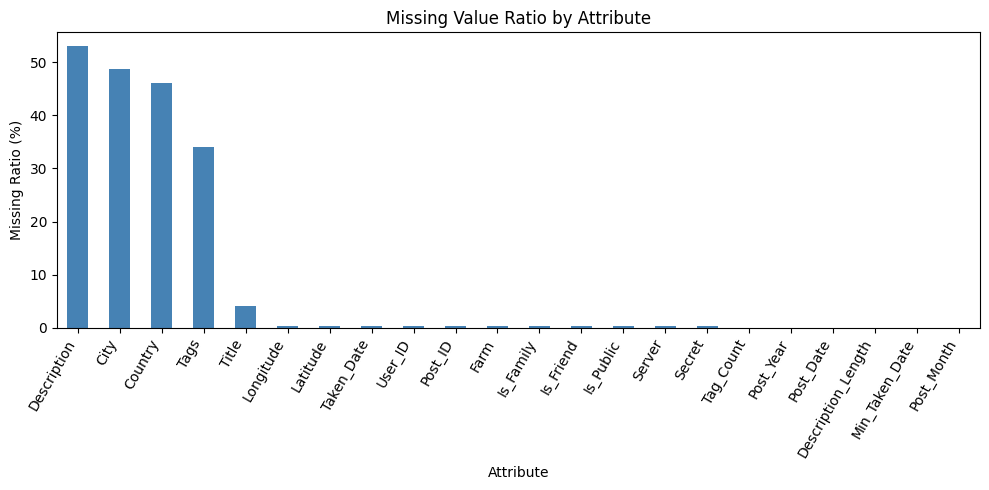

In [175]:
missing_ratio = (eda_df.isna().mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
missing_ratio.plot(kind="bar", color="steelblue")
plt.title("Missing Value Ratio by Attribute")
plt.ylabel("Missing Ratio (%)")
plt.xlabel("Attribute")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

### 2.2 Univariate Analysis


- Top countries
- Top cities
- Number of posts by year
- Top tags

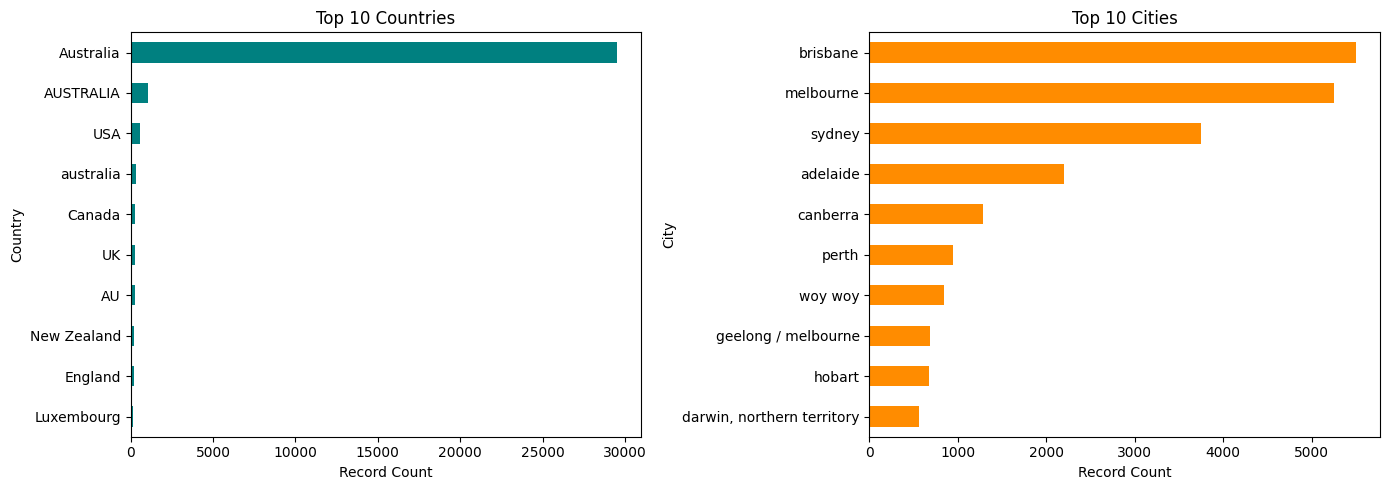

Country
Australia      29514
AUSTRALIA       1057
USA              540
australia        336
Canada           265
UK               264
AU               234
New Zealand      219
England          214
Luxembourg       160
Name: count, dtype: int64

City
brisbane                      5496
melbourne                     5251
sydney                        3753
adelaide                      2201
canberra                      1287
perth                          949
woy woy                        845
geelong / melbourne            691
hobart                         672
darwin, northern territory     563
Name: count, dtype: int64

In [176]:
top_countries = eda_df["Country"].dropna().value_counts().head(10)
top_cities = eda_df["City"].dropna().value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_countries.sort_values().plot(kind="barh", ax=axes[0], color="teal")
axes[0].set_title("Top 10 Countries")
axes[0].set_xlabel("Record Count")

top_cities.sort_values().plot(kind="barh", ax=axes[1], color="darkorange")
axes[1].set_title("Top 10 Cities")
axes[1].set_xlabel("Record Count")

plt.tight_layout()
plt.show()
display(top_countries)
display(top_cities)

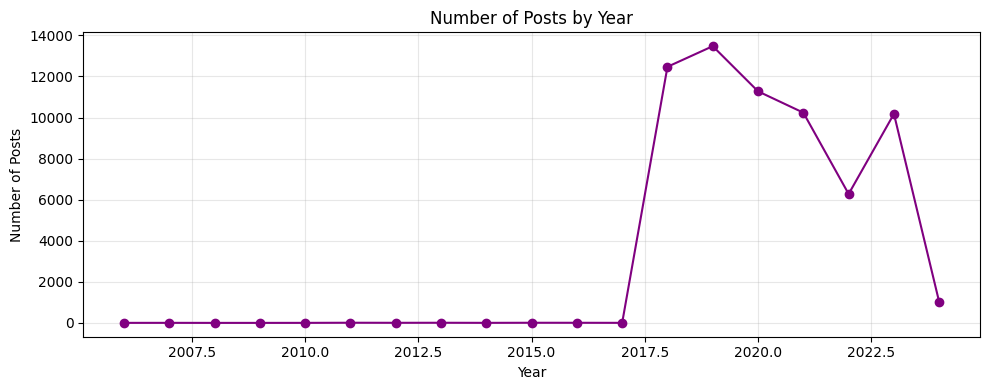

Post_Year
2006        2
2007        3
2008        1
2009        1
2010        2
2011        8
2012        5
2013        7
2014        3
2015        7
2016        6
2017        3
2018    12469
2019    13473
2020    11274
2021    10235
2022     6277
2023    10176
2024     1008
Name: count, dtype: int64

In [178]:
post_year_counts = eda_df["Post_Year"].dropna().astype(int).value_counts().sort_index()

plt.figure(figsize=(10, 4))
post_year_counts.plot(kind="line", marker="o", color="purple")
plt.title("Number of Posts by Year")
plt.xlabel("Year")
plt.ylabel("Number of Posts")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
display(post_year_counts)

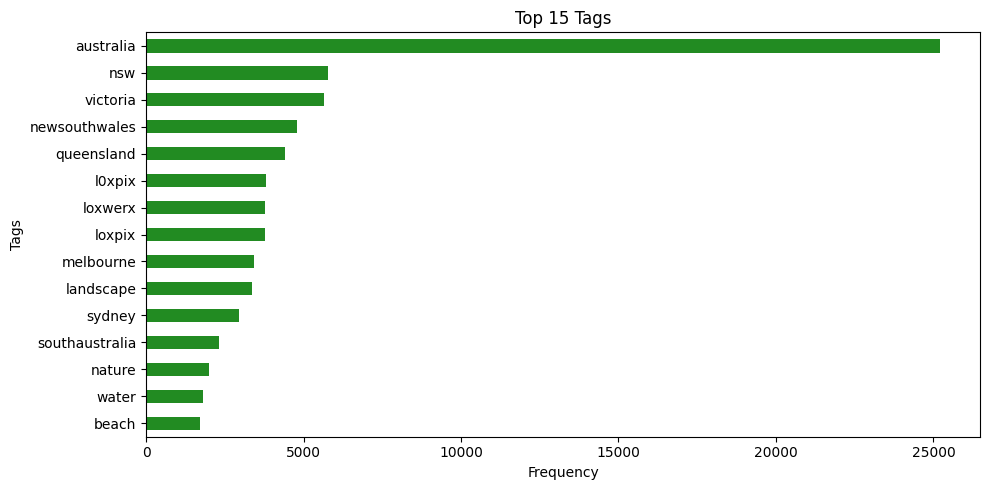

Tags
australia         25218
nsw                5778
victoria           5651
newsouthwales      4780
queensland         4411
l0xpix             3808
loxwerx            3771
loxpix             3762
melbourne          3442
landscape          3352
sydney             2957
southaustralia     2312
nature             1986
water              1812
beach              1724
Name: count, dtype: int64

In [179]:
tag_series = (
    eda_df["Tags"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
)
tag_series = tag_series[tag_series.ne("")]
top_tags = tag_series.value_counts().head(15)

plt.figure(figsize=(10, 5))
top_tags.sort_values().plot(kind="barh", color="forestgreen")
plt.title("Top 15 Tags")
plt.xlabel("Frequency")
plt.tight_layout()
plt.show()
display(top_tags)

### 2.3 Bivariate Analysis


- top 5 countries over time
- geographical scatter plot

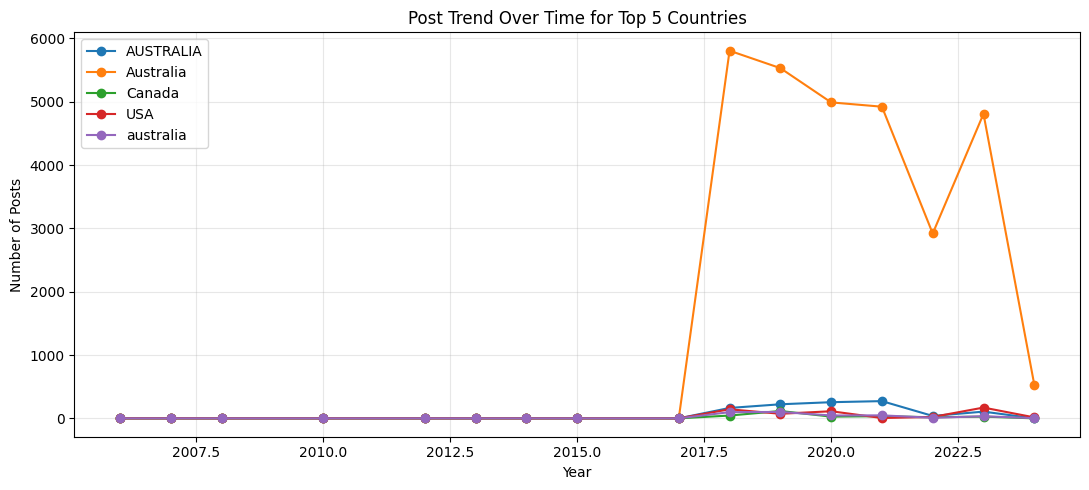

Country,AUSTRALIA,Australia,Canada,USA,australia
Post_Year,,,,,
2006,0,1,0,0,0
2007,0,0,0,1,0
2008,0,1,0,0,0
2010,0,2,0,0,0
2012,0,1,0,0,0
2013,0,2,0,0,0
2014,0,1,0,0,0
2015,0,2,0,0,0
2017,0,1,0,0,0


In [180]:
country_year_df = eda_df.dropna(subset=["Country", "Post_Year"]).copy()
top5_countries = country_year_df["Country"].value_counts().head(5).index.tolist()
country_year_df = country_year_df[country_year_df["Country"].isin(top5_countries)]

country_year_counts = country_year_df.groupby(["Post_Year", "Country"]).size().unstack(fill_value=0).sort_index()

plt.figure(figsize=(11, 5))
for country in country_year_counts.columns:
    plt.plot(country_year_counts.index, country_year_counts[country], marker="o", label=country)
plt.title("Post Trend Over Time for Top 5 Countries")
plt.xlabel("Year")
plt.ylabel("Number of Posts")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
display(country_year_counts)

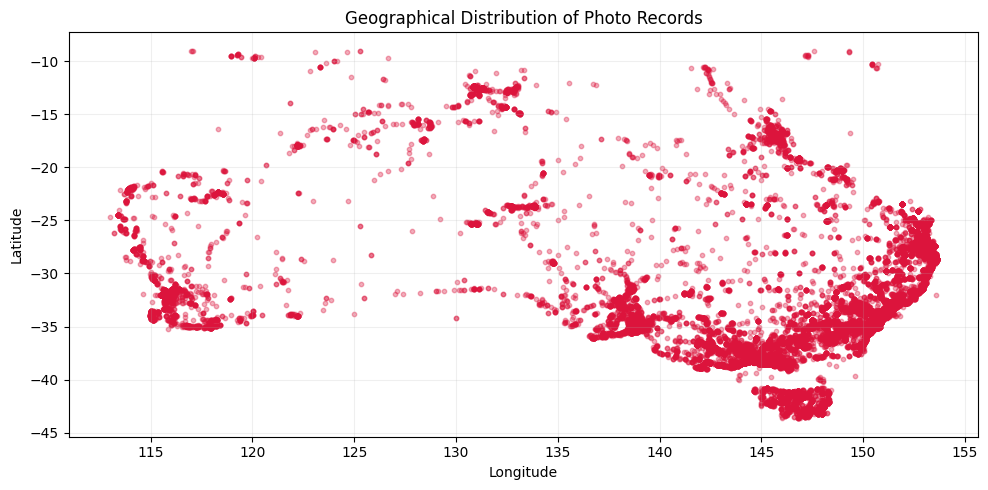

In [181]:
geo_df = eda_df.dropna(subset=["Latitude", "Longitude"]).copy()

plt.figure(figsize=(10, 5))
plt.scatter(geo_df["Longitude"], geo_df["Latitude"], alpha=0.35, s=10, color="crimson")
plt.title("Geographical Distribution of Photo Records")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### 2.4 Multivariate Analysis



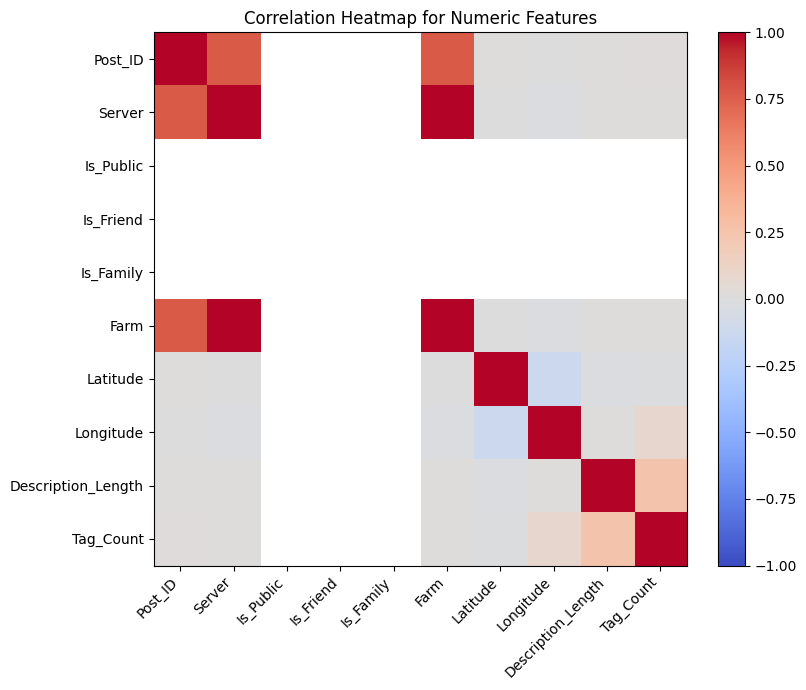

,Post_ID,Server,Is_Public,Is_Friend,Is_Family,Farm,Latitude,Longitude,Description_Length,Tag_Count
Post_ID,1.000,0.773,NaN,NaN,NaN,0.773,0.003,-0.001,0.001,0.009
Server,0.773,1.000,NaN,NaN,NaN,1.000,-0.006,-0.017,0.007,0.004
Is_Public,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Is_Friend,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Is_Family,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm,0.773,1.000,NaN,NaN,NaN,1.000,-0.006,-0.017,0.007,0.004
Latitude,0.003,-0.006,NaN,NaN,NaN,-0.006,1.000,-0.119,-0.022,-0.012
Longitude,-0.001,-0.017,NaN,NaN,NaN,-0.017,-0.119,1.000,0.005,0.080
Description_Length,0.001,0.007,NaN,NaN,NaN,0.007,-0.022,0.005,1.000,0.256
Tag_Count,0.009,0.004,NaN,NaN,NaN,0.004,-0.012,0.080,0.256,1.000


In [182]:
numeric_cols = ["Post_ID", "Server", "Is_Public", "Is_Friend", "Is_Family", "Farm", "Latitude", "Longitude", "Description_Length", "Tag_Count"]
corr = eda_df[numeric_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
ax.set_title("Correlation Heatmap for Numeric Features")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()
display(corr.round(3))

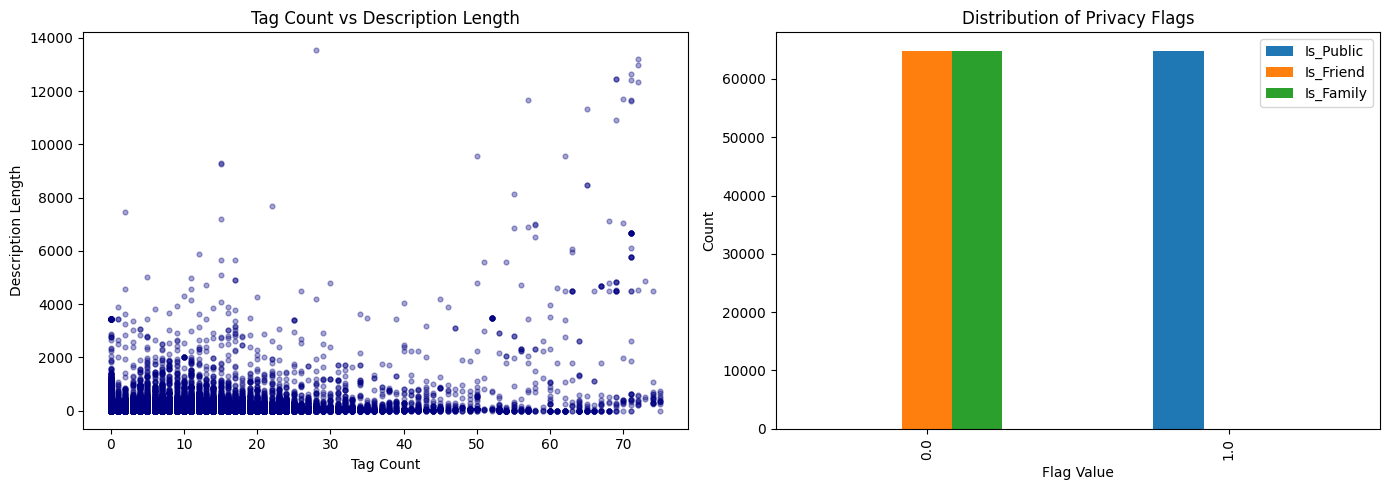

,Is_Public,Is_Friend,Is_Family
0.0,0.0,64764.0,64764.0
1.0,64764.0,0.0,0.0


In [183]:
plot_df = eda_df.dropna(subset=["Description_Length", "Tag_Count"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(plot_df["Tag_Count"], plot_df["Description_Length"], alpha=0.35, s=12, color="navy")
axes[0].set_title("Tag Count vs Description Length")
axes[0].set_xlabel("Tag Count")
axes[0].set_ylabel("Description Length")

privacy_summary = eda_df[["Is_Public", "Is_Friend", "Is_Family"]].apply(pd.Series.value_counts).fillna(0)
privacy_summary.plot(kind="bar", ax=axes[1], color=["#1f77b4", "#ff7f0e", "#2ca02c"])
axes[1].set_title("Distribution of Privacy Flags")
axes[1].set_xlabel("Flag Value")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()
display(privacy_summary)

## 3. Key Insights and ML Questions

1. 数据在地理上高度集中，`Australia` 占绝对多数，说明数据分布明显偏向澳洲场景，而不是全球均匀分布。
2. 文本和地点字段缺失很严重，例如 `Description` 缺失约 55.37%，`City` 缺失约 48.68%，`Country` 缺失约 46.12%，说明原始 metadata 完整度不均衡。

4. 城市分布集中在 `Brisbane`, `Melbourne`, `Sydney`, `Adelaide`, `Canberra` 等澳洲城市，进一步支持地理集中这一发现。
5. 国家字段存在标准不统一问题，例如 `australia`, `au`, `aus` 同时出现，说明 location standardisation 会是后续建模前的重要 preprocessing 工作。
6. 标签呈明显长尾分布，高频标签如 `australia`, `nsw`, `victoria`, `newsouthwales`, `queensland` 占据大量记录，说明主题高度集中在地点相关内容。
7. 时间分布不均匀，2020 到 2023 年明显更活跃，适合进一步讨论时间趋势、活跃周期和 forecasting 问题。
8. 由于 `Is_Public`, `Is_Friend`, `Is_Family` 大概率方差很低，这类隐私字段对建模的区分能力可能有限。
9. 这个数据集同时有结构化字段、文本字段、时间字段和地理坐标，因此适合分类、聚类、时间序列和数据补全等多类机器学习问题。
10. 由于文本缺失较多但标签相对更稳定，后续建模时 `Tags` 可能比 `Description` 提供更强的主题信息。

### 3.1 写 Insight 的标准

- insight 不能只是“某个值大/小”
- 要结合图和表说明为什么这个发现重要
- 要尽量和 data quality、pattern、business value 或 ML task 连接起来
- 2026 版更重视高质量 insight，而不是堆很多模糊句子

### 3.2 写 ML Question 的标准

每个问题最好都说清楚：

- 输入特征是什么
- 输出变量是什么
- 属于哪类 ML 任务
- 为什么这个问题合理
- 为什么对这份数据有实际价值

### 3.2 示例 ML Questions

#### Q1. 能否根据标题、标签、描述和坐标预测帖子所属国家？
- 类型：监督学习分类
- 输入：`Title`, `Tags`, `Description`, `Latitude`, `Longitude`
- 输出：`Country`
- 为什么适合这组数据：`Country` 缺失接近一半，但 `Tags` 和经纬度包含明显地点信息
- 价值：补全缺失 metadata，提高数据完整性

#### Q2. 能否根据历史发帖数量预测未来某个国家/城市的发帖趋势？
- 类型：时间序列预测 / 回归
- 输入：时间窗口内的历史数量、地点信息、lag features
- 输出：未来发帖数
- 为什么适合这组数据：2020 到 2023 年的发帖量明显更高，存在较清晰的时间变化
- 价值：趋势预测与活跃度监控

#### Q3. 能否根据用户发帖频率、标签偏好、地理分布对用户进行聚类？
- 类型：无监督学习聚类
- 输入：user-level 聚合特征
- 输出：cluster labels
- 为什么适合这组数据：标签和地点分布都很集中，适合构建用户画像特征
- 价值：用户画像与行为分群

#### Q4. 能否用空间和文本特征识别异常帖子或异常热点区域？
- 类型：异常检测
- 输入：坐标、时间、标签数、描述长度等
- 输出：异常分数 / 异常标签
- 为什么适合这组数据：整体热点集中在澳洲主要城市，离群点和异常区域更容易被识别
- 价值：发现异常事件或异常数据

#### Q5. 能否根据其他元数据推断缺失的 `City` 或 `Country`？
- 类型：监督学习 / 半监督学习
- 输入：文本字段、坐标、时间特征、用户特征
- 输出：缺失地点字段
- 为什么适合这组数据：`City` 和 `Country` 缺失比例都很高，是最直接的数据补全场景
- 价值：数据补全，提高后续分析质量

## 4. Tutor 讲解提示


1. 先讲 sample output，再讲清洗，再讲 EDA
2. 强调 deduplication 和 non-Latin cleaning 是 2026 版关键变化
3. 强调 EDA 阶段要把字符串 `NaN` 还原成真正缺失值
4. 每张图都要服务于后面的 insight 和 ML question
5. 学生最容易丢分的地方还是：字段顺序、清洗规则、问题写得太空泛